In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [12]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


In [13]:
print(x_train.shape)  # (60000, 28, 28)
print(x_test.shape)   # (10000, 28, 28)


(60000, 28, 28)
(10000, 28, 28)


In [14]:
x_train = x_train / 255.0
x_test = x_test / 255.0


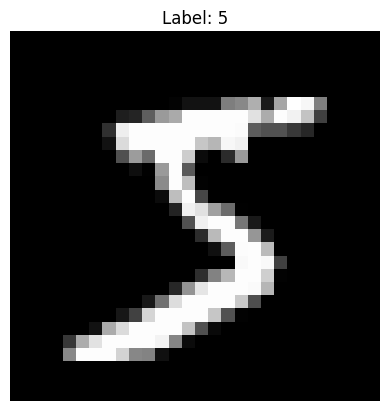

In [15]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


In [16]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8732 - loss: 0.4541 - val_accuracy: 0.9647 - val_loss: 0.1329
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9613 - loss: 0.1317 - val_accuracy: 0.9723 - val_loss: 0.1007
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9755 - loss: 0.0838 - val_accuracy: 0.9758 - val_loss: 0.0887
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9816 - loss: 0.0620 - val_accuracy: 0.9762 - val_loss: 0.0783
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9775 - val_loss: 0.0759


In [19]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0813
Test Accuracy: 0.9772


In [20]:
predictions = model.predict(x_test)

# Predicted class for first test image
predicted_label = tf.argmax(predictions[0]).numpy()
print("Predicted:", predicted_label)
print("Actual:", y_test[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted: 7
Actual: 7


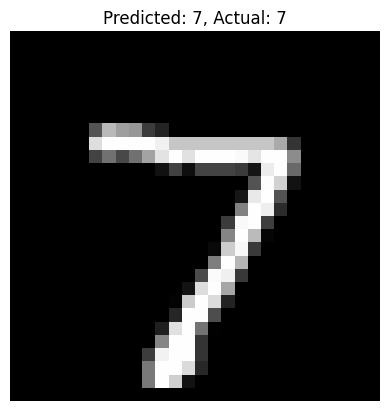

In [21]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {y_test[0]}")
plt.axis('off')
plt.show()
